In [12]:
import h5py
import txpipe.data_types

import numpy as np
import matplotlib.pyplot as plt
import pyarrow.parquet as pq
import sacc


In [3]:
f = pq.ParquetFile('/Users/jzuntz/src/euclid/data/euclid_rr2_r1_v2_1.parquet')

In [6]:
tiles = f.read(["tile_index"])

In [9]:
bad_tiles = [102016422, 102016856, 102016857, 102016423, 102016424, 102017297, 102016858, 102019131, 102018674, 102018672, 102019596, 102019132, 102018673, 102019133, 102042322, 102041693, 102041070, 102041069, 102041695, 102041694]
for bad_tile in bad_tiles:
    if bad_tiles in tiles:
        raise ValueError(f"Bad tile {bad_tile} found in data!")

In [42]:
sc = f.schema

In [47]:
for name in sc.names:
    if "lensmc" in name:
        print(name)

she_lensmc_fit_flags
she_lensmc_val_flags
she_lensmc_fit_class
she_lensmc_nexp
she_lensmc_unmasked_fraction
she_lensmc_rec_flags
she_lensmc_e1
she_lensmc_e1_err
she_lensmc_e2
she_lensmc_e2_err
she_lensmc_e_var
she_lensmc_e1e2_covar
she_lensmc_weight
she_lensmc_e1_corrected
she_lensmc_e1_corrected_err
she_lensmc_e2_corrected
she_lensmc_e2_corrected_err
she_lensmc_e_corrected_var
she_lensmc_e1e2_corrected_covar
she_lensmc_weight_cal
she_lensmc_m11
she_lensmc_m12
she_lensmc_m21
she_lensmc_m22
she_lensmc_c1
she_lensmc_c2
she_lensmc_alpha1
she_lensmc_alpha2
she_lensmc_psf_e1
she_lensmc_psf_e2
she_lensmc_psf_r2
she_lensmc_ra
she_lensmc_ra_err
she_lensmc_dec
she_lensmc_dec_err
she_lensmc_re
she_lensmc_re_err
she_lensmc_flux
she_lensmc_flux_err
she_lensmc_mag
she_lensmc_mag_err
she_lensmc_snr
she_lensmc_snr_err
she_lensmc_flux_bulge
she_lensmc_flux_bulge_err
she_lensmc_flux_disk
she_lensmc_flux_disk_err
she_lensmc_zp
she_lensmc_bulge_frac
she_lensmc_bulge_frac_err
she_lensmc_hlr
she_lensmc_hlr

In [27]:
cols = ["she_metacal_r2", "tom_bin_id", "she_metacal_sn", "she_metacal_e1", "she_metacal_e2", "she_metacal_e1_corrected", "she_metacal_e2_corrected"]
data = f.read(cols).to_pandas()

In [28]:
data = data.query("tom_bin_id>=0")

In [30]:
data

,she_metacal_r2,tom_bin_id,she_metacal_sn,she_metacal_e1,she_metacal_e2,she_metacal_e1_corrected,she_metacal_e2_corrected
16,NaN,6,NaN,NaN,NaN,NaN,NaN
20,0.039121,4,118.990342,0.162969,0.344059,0.179835,0.336635
22,0.039503,2,186.207891,0.152249,0.108686,0.165935,0.104054
25,0.039255,2,139.576519,0.203175,-0.118697,0.214833,-0.121172
27,0.049012,2,175.341397,-0.435358,0.062858,-0.423570,0.059378
...,...,...,...,...,...,...,...
175406952,0.021873,6,47.843308,-0.229341,0.202299,-0.235873,0.198065
175406953,0.014162,1,402.116475,-0.014007,-0.039499,NaN,NaN
175406955,NaN,3,NaN,NaN,NaN,NaN,NaN
175406957,0.029343,2,68.345498,0.091669,0.002004,0.090184,-0.007378


In [10]:
m = txpipe.data_types.MapsFile("data/euclid-rr2/outputs-2_1/source_maps.hdf5", "r")

In [12]:
m.list_maps()

['count_0',
 'count_1',
 'count_2',
 'count_2D',
 'count_3',
 'count_4',
 'count_5',
 'g1_0',
 'g1_1',
 'g1_2',
 'g1_2D',
 'g1_3',
 'g1_4',
 'g1_5',
 'g2_0',
 'g2_1',
 'g2_2',
 'g2_2D',
 'g2_3',
 'g2_4',
 'g2_5',
 'lensing_weight_0',
 'lensing_weight_1',
 'lensing_weight_2',
 'lensing_weight_2D',
 'lensing_weight_3',
 'lensing_weight_4',
 'lensing_weight_5',
 'var_e_0',
 'var_e_1',
 'var_e_2',
 'var_e_2D',
 'var_e_3',
 'var_e_4',
 'var_e_5',
 'var_g1_0',
 'var_g1_1',
 'var_g1_2',
 'var_g1_2D',
 'var_g1_3',
 'var_g1_4',
 'var_g1_5',
 'var_g2_0',
 'var_g2_1',
 'var_g2_2',
 'var_g2_2D',
 'var_g2_3',
 'var_g2_4',
 'var_g2_5']

In [14]:
c = m.read_map("count_0")

In [16]:
import healpy

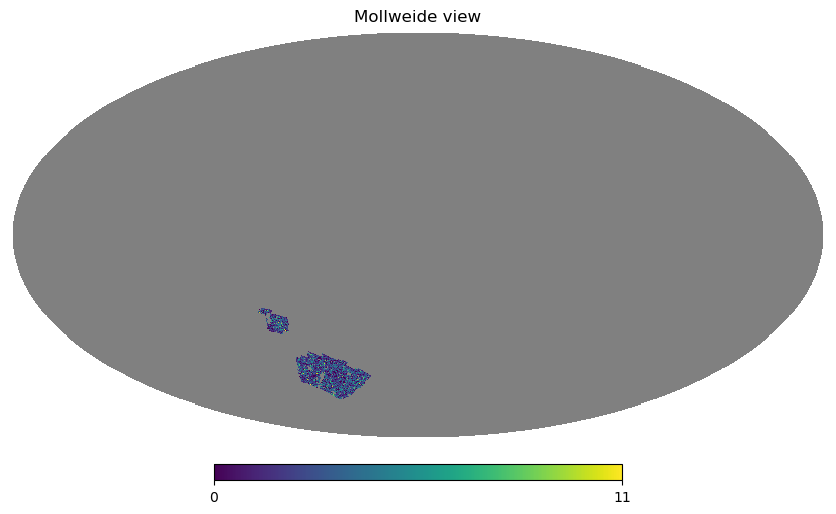

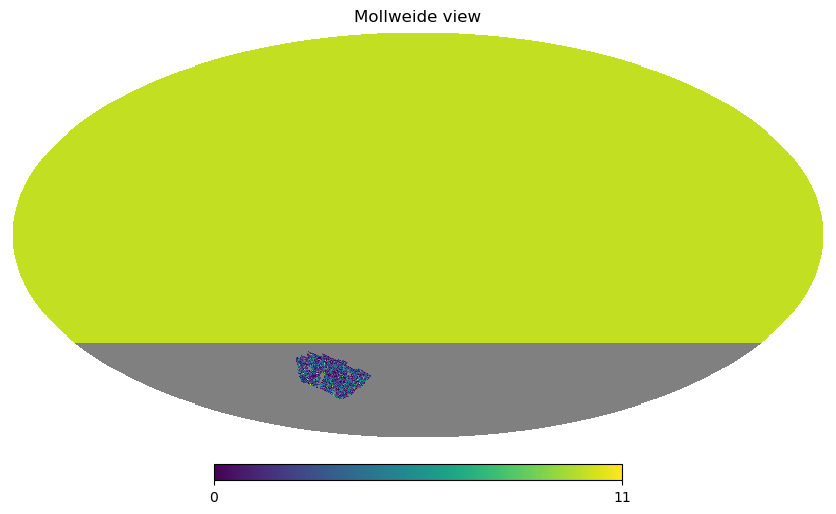

In [22]:
healpy.mollview(c)
npix = len(c)
nside = healpy.npix2nside(npix)
pix = np.arange(npix)
lon, lat = healpy.pix2ang(nside, pix, lonlat=True)
c2 = c.copy()
c2[lat > -40] = 10
healpy.mollview(c2)

In [31]:
import sacc
import qp
s = sacc.Sacc.load_fits("data/euclid-rr2/outputs-2_1/twopoint_theory_real.sacc")

In [32]:
s.tracers


{'source_0': <sacc.tracers.nz.NZTracer at 0x1774f7370>,
 'source_1': <sacc.tracers.nz.NZTracer at 0x1774f6cb0>,
 'source_2': <sacc.tracers.nz.NZTracer at 0x1774f7010>,
 'source_3': <sacc.tracers.nz.NZTracer at 0x1774f7880>,
 'source_4': <sacc.tracers.nz.NZTracer at 0x1774f5de0>,
 'source_5': <sacc.tracers.nz.NZTracer at 0x1774f5c90>}

In [70]:
s = sacc.Sacc.load_fits("data/euclid-rr2/outputs-2_1/summary_statistics_real.sacc")

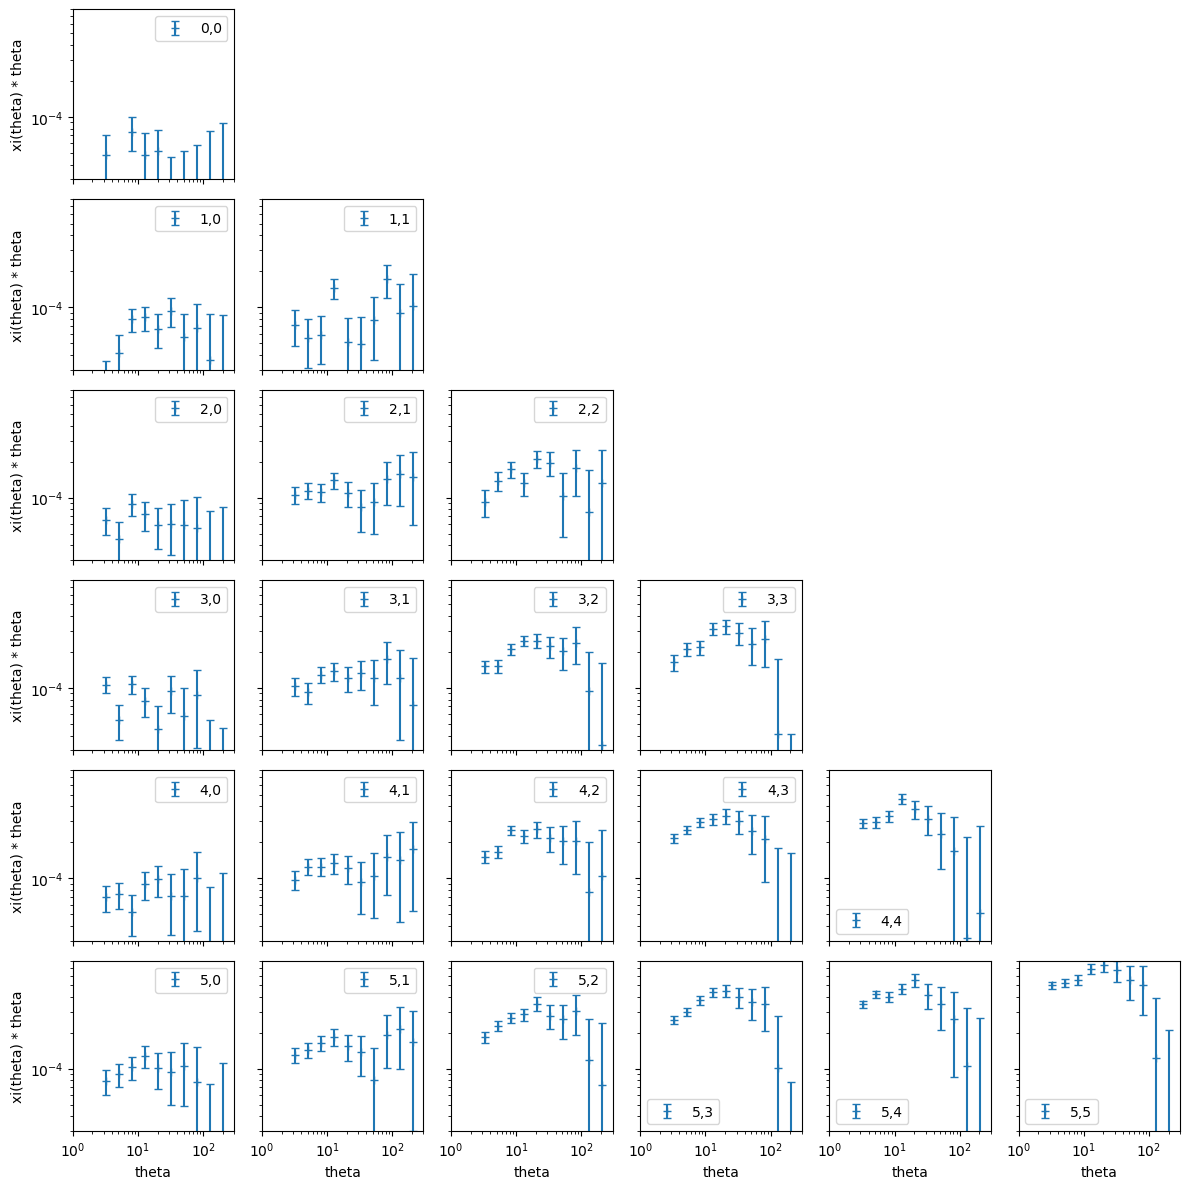

In [86]:
bins = set()
for (bin1, bin2) in s.get_tracer_combinations("galaxy_shear_xi_plus"):
    bins.add(bin1)
    bins.add(bin2)
bins = sorted(bins)
nbin = len(bins)

fig, axes = plt.subplots(nbin, nbin, figsize=(12, 12))

used = np.zeros((nbin, nbin), dtype=bool)

for bin1, bin2 in s.get_tracer_combinations("galaxy_shear_xi_plus"):
    theta, xi, cov = s.get_theta_xi("galaxy_shear_xi_plus", bin1, bin2, return_cov=True)
    err = np.sqrt(np.diag(cov))
    b1 = bins.index(bin1)
    b2 = bins.index(bin2)
    ax = axes[b1, b2]
    t1 = bin1.split("_")[-1]
    t2 = bin2.split("_")[-1]
    ax.errorbar(theta, xi * theta, yerr=err * theta, fmt="+", capsize=3, label=f"{t1},{t2}")
    ax.legend()
    ax.set_xscale("log")
    ax.set_yscale("log")
    if b1 == nbin - 1:
        ax.set_xlabel("theta")
    else:
        ax.set_xticklabels([])
    if b2 == 0:
        ax.set_ylabel("xi(theta) * theta")
    else:
        ax.set_yticklabels([])
    ax.set_xlim(1, 300)
    ax.set_ylim(3e-5, 8e-4)
    used[b1, b2] = True
for i in range(nbin):
    for j in range(nbin):
        if not used[i, j]:
            axes[i, j].axis("off")

fig.tight_layout()



In [118]:
import sacc
import qp
s = sacc.Sacc.load_fits("/Users/jzuntz/src/cosmosis/cosmosis-standard-library/reduced_euclid_rr2_2.1_summary_statistics_fourier.sacc")
s2 = sacc.Sacc.load_fits("data/euclid-rr2/outputs-2_1/summary_statistics_fourier.sacc")
s3 = sacc.Sacc.load_fits("data/euclid-rr2/outputs-2_1/twopoint_data_fourier.sacc")

In [116]:
s.get_data_types()

['galaxy_shear_cl_ee']

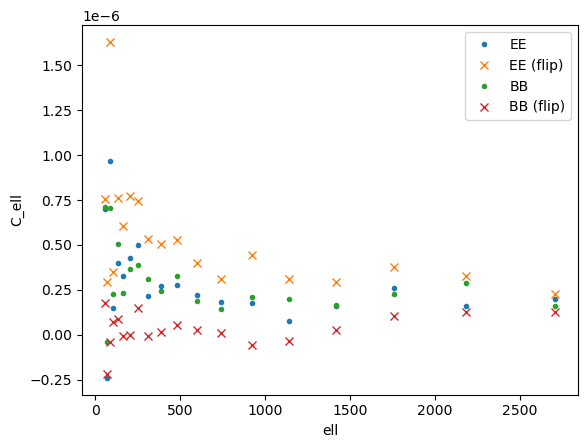

In [14]:
s1 = sacc.Sacc.load_fits("data/euclid-rr2/outputs-2_1/twopoint_data_fourier.sacc")
s2 = sacc.Sacc.load_fits("data/euclid-rr2/outputs-2_1/twopoint_data_fourier_flip2.sacc")

ell, ee = s1.get_ell_cl("galaxy_shear_cl_ee", "source_4", "source_4")
ell2, ee2 = s2.get_ell_cl("galaxy_shear_cl_ee", "source_4", "source_4")
plt.plot(ell, ell*ee, ".", label='EE')
plt.plot(ell2, ell2*ee2, "x", label='EE (flip)')

ell, bb = s1.get_ell_cl("galaxy_shear_cl_bb", "source_4", "source_4")
ell2, bb2 = s2.get_ell_cl("galaxy_shear_cl_bb", "source_4", "source_4")
plt.plot(ell, ell*bb, ".", label='BB')
plt.plot(ell2, ell2*bb2, "x", label='BB (flip)')


plt.xlabel("ell")
plt.ylabel("C_ell")
plt.legend()

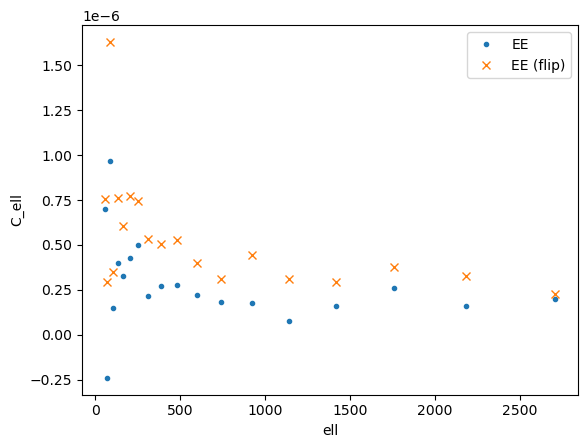

In [15]:
s1 = sacc.Sacc.load_fits("data/euclid-rr2/outputs-2_1/summary_statistics_fourier.sacc")
s2 = sacc.Sacc.load_fits("data/euclid-rr2/outputs-2_1/summary_statistics_fourier_flip2.sacc")

ell, ee = s1.get_ell_cl("galaxy_shear_cl_ee", "source_4", "source_4")
ell2, ee2 = s2.get_ell_cl("galaxy_shear_cl_ee", "source_4", "source_4")
plt.plot(ell, ell*ee, ".", label='EE')
plt.plot(ell2, ell2*ee2, "x", label='EE (flip)')



plt.xlabel("ell")
plt.ylabel("C_ell")
plt.legend()

In [35]:
s1.metadata['provenance/config/flip_g2'], s2.metadata['provenance/config/flip_g2']

('False', 'True')

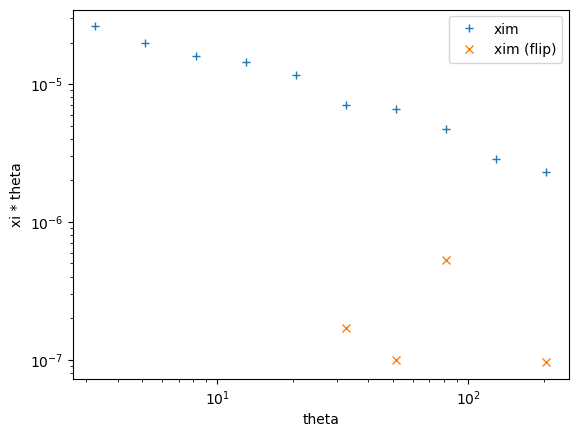

In [41]:
s1 = sacc.Sacc.load_fits("data/euclid-rr2/outputs-2_1/twopoint_data_real_raw.sacc")
s2 = sacc.Sacc.load_fits("data/euclid-rr2/outputs-2_1/twopoint_data_real_raw_flip2.sacc")

theta1, xi1 = s1.get_theta_xi("galaxy_shear_xi_minus", "source_4", "source_4")
theta2, xi2 = s2.get_theta_xi("galaxy_shear_xi_minus", "source_4", "source_4")
plt.loglog(theta1, xi1, "+", label='xim')
plt.loglog(theta2, xi2, "x", label='xim (flip)')



plt.xlabel("theta")
plt.ylabel("xi * theta")
plt.legend()

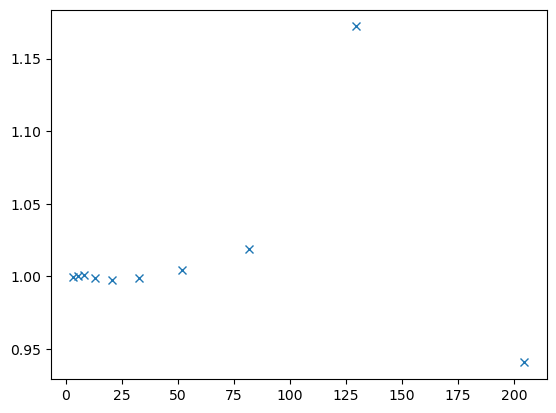

In [38]:
plt.plot(theta2, xi2/xi1, "x", label='xip (flip)')
